# ⚛️   Atomic-Radii 

**Linear Regression / Polynomial Regression & Random Forest (first look)**


The data set : [atomic_radii_dataset.csv](data/lec04-atomic_radii_dataset.csv) consists of the variables Element,Atomic_Number,Period,Group,Electronegativity,Atomic_Radius_pm.

Our dependent variable or target (y) is the atomic radius and all others can be independent variables (X).

Our objective is to build a model where we can take one or more of the independent (X) variables and accurately predict the target (y).

And of course we know the chemistry/physics of the atomic arrangment is far too complex to be modeled by simple models like regression, but just treat this as an exercise to practice your ML skills as well as understand the limitations of such approaches.

In [1]:
#We usually import all the necessary packages at the top - keeps the code clean
#Essential packages - numpy, pandas, matplotlib, seaborn
# ✅

import numpy as np         # datastructure : array
import pandas as pd        # datastructure : dataframe (also Series)
import matplotlib.pyplot as plt     #plot
import seaborn as sns #plot

import math
#ML packages
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report


#If you need to add a package half-way through the code, you can - there's nothing technically wrong with it
#But as a best practice you should come back up and add it here, and then RUN the cell (and run all the following cells)

In [3]:
#Read the data - and name it as a variable
df = pd.read_csv("data/lec04-atomic_radii_dataset.csv")

In [4]:
#Inspect the data - very important to 'see' the data that we are dealing with
df.head(10)

,Element,Atomic_Number,Period,Group,Electronegativity,Atomic_Radius_pm
0,H,1,1,1,2.20,53
1,He,2,1,18,NaN,31
2,Li,3,2,1,0.98,152
3,Be,4,2,2,1.57,112
4,B,5,2,13,2.04,85
5,C,6,2,14,2.55,70
6,N,7,2,15,3.04,65
7,O,8,2,16,3.44,60
8,F,9,2,17,3.98,50
9,Ne,10,2,18,NaN,38


In [5]:
#There seems to be some missing data
df.isna()


,Element,Atomic_Number,Period,Group,Electronegativity,Atomic_Radius_pm
0,False,False,False,False,False,False
1,False,False,False,False,True,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,True,False


# ❓ Can you get a summarised version of the above?

**useful when you have a big dataset**

In [6]:
#✅
df.isna().sum()

Element              0
Atomic_Number        0
Period               0
Group                0
Electronegativity    4
Atomic_Radius_pm     0
dtype: int64

# ⁉ How to deal with missing data

We can look at the common approaches we talked about

Option 1: Delete them from the dataset

*   If you have a big dataset and deleting a few values doesn't affect the outcome
*   The rows/columns containing the missing data is not relevant for your calculation

```
# df = df.dropna(axis=1,how="any") # drop the entire column containing missing values
# df = df.dropna(axis=0,how="any") # drop the entire column containing missing values
```

Option 2: Insert the missing values using reference database
*   If the dataset is too small and every datapoint is important
*   If the number of missing datapoints are small enough to be manually inserted

Option 3: Impute the missing value using a statistical basis
*   Using the mean/median/mode value of the rest of the column
*   The error introduced is not significant in the final outcome


**❗❗But wait❗❗** 

👀 Look at the missing data - they are electronegativity values for the elements like *He*,*Ne*, ...the inert (noble) gases!

Now it's your time to use your domain expertise - does it make sense to impute the mean of the other elements to assign an electronegativity value for these closed-shell, non-bonding elements? 🤔

Filling with the dataset mean (~1.9–2.0 on Pauling's scale) puts noble gases in the same electronegativity neighborhood as, say, zinc or germanium - implying a moderate tendency to attract bonding electrons.

So, then should you drop them? It's a very small dataset - and you can't import any extra data to fill the gap because you can't make up elements!

**What would make more sense, depends on the goal:**

1. Drop those rows for any model that uses Electronegativity as a feature, and say explicitly that Pauling EN is undefined for noble gases - this is the most defensible option.
2. A smarter option would be to switch the whole column to a scale that's actually defined for noble gases, e.g. the Allen scale, which is derived from spectroscopic valence-electron energies rather than bond energies. Interesting twist: on the Allen scale, neon is the single most electronegative element of all, with helium close behind (He ≈ 4.16, Ne ≈ 4.79, Ar ≈ 3.24, Kr ≈ 2.97) - the opposite direction from what mean-imputation implies. That means mixing scales for 4 rows and Pauling for the rest would be its own inconsistency, so this only makes sense if you convert the entire column.
3. If you need some numeric placeholder and don't want to change scales, something close to 0 is a more defensible approximation than the mean (reflecting "negligible tendency to share bonding electrons"), but it's still a stand-in, not a real Pauling value, and should be labeled as such.

So, what do we want to do? Just to keep things simple (and assuming that electronegativity is not going to play a major role in determining the atomic radii here), let's do an imputation - and assign a value to these missing data.


⚠️ **One more thing to be careful about:** 

It also matters *when* you compute that mean, not just which method you use. If you calculate it from the *whole* dataset before splitting into train/test, information about your test rows has quietly leaked into a number your "training" pipeline relies on. For just eyeballing the data that's harmless - but the moment a statistic like this actually feeds a model (as Electronegativity will, later, for our classifier), it needs to be computed from the **training set only** and then applied to the test set. Below we do the quick version just to look at the data, and redo it properly, later, right before we use Electronegativity as a model feature.

In [7]:
#Let's check the length of the data - can you afford to delete the missing data?
# use the len() function ✅

len(df)

36

In [8]:
# Fill missing EN (noble gases) with mean - PREVIEW ONLY, not saved back to df yet.
# (see the note above: we don't actually use Electronegativity as a model feature until the
# classification section near the end, so we hold off on permanently filling it until then,
# and we'll compute the fill value from the training set only when we get there)
df["Electronegativity"].fillna(df["Electronegativity"].mean()).head(10)

0    2.20000
1    1.99125
2    0.98000
3    1.57000
4    2.04000
5    2.55000
6    3.04000
7    3.44000
8    3.98000
9    1.99125
Name: Electronegativity, dtype: float64

In [10]:
#Just double checking
# Electronegativity will still show 4 missing here - that's expected, see the note above.
# Everything else should be 0.
df.isna().sum()

Element              0
Atomic_Number        0
Period               0
Group                0
Electronegativity    4
Atomic_Radius_pm     0
dtype: int64

In [53]:
#Separating the X (independent) and y (dependent) variables for convenience
y = df[["Atomic_Radius_pm"]]    #target
X = df[["Atomic_Number"]]       #features

In [12]:
#check the data type of y
type(y)

pandas.core.frame.DataFrame

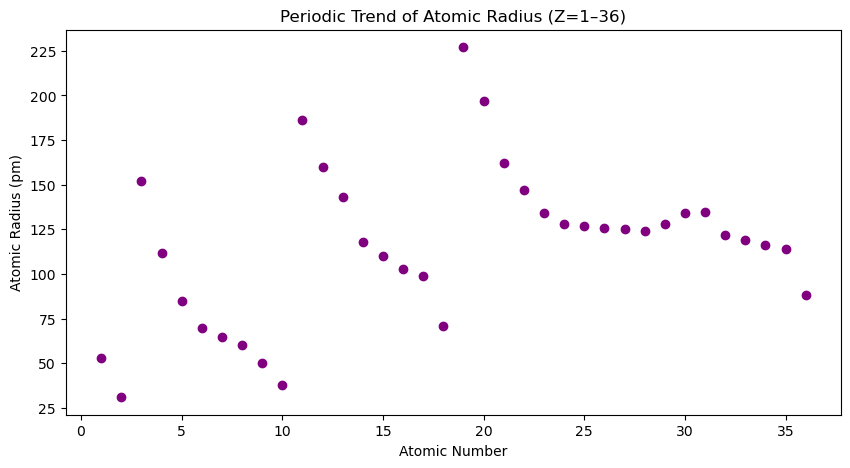

In [13]:
#Let's plot this to see
plt.figure(figsize=(10,5))
plt.scatter(df["Atomic_Number"], df["Atomic_Radius_pm"],c="purple")
plt.xlabel("Atomic Number")
plt.ylabel("Atomic Radius (pm)")
plt.title("Periodic Trend of Atomic Radius (Z=1–36)")
plt.show()

# ⚡ Train - Test Split

When we build a ML model we don't use the whole dataset to do it.
Instead, we split it into two (sometimes three) sets, called training, testing (and validation) datasets.
Training set - majority of the data (generally 60%-80%)
Testing set - small portion (20%-25% is common)
Validation set - Only needed if you are using data to make modeling decisions (tune hyper-parameters/ choose models/ choose features etc.) (~20%)


❓**Why do we split the data?**

We build the model on the training data, and test the performance using test data. So it acts as an independent evaluation of the model performance. So ideally the model should not 'see' the test data during training time. This means there should be no duplicates (across train and test), there should be no statistics of the overal distribution in the test set (i.e. should not normalize the dataset before splitting)

In [14]:
#for this we will do a simple train/test split
#If you need a validation set, you can simply use this same function twice
# ✅ Use train_test_split() function

# Using random_state=42 here (and again below for the multi-variable split) so that every
# model in this notebook is compared on the SAME train/test partition. Using different seeds
# in different sections would make the R² values below not directly comparable to each other.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()

,Atomic_Number
8,9
17,18
9,10
34,35
0,1


In [15]:
#Print the train/test set lengths to confirm
print("length of X train:",len(X_train),"& length of y train",len(y_train))
print("length of X test:",len(X_test),"& length of y test",len(y_test))

length of X train: 28 & length of y train 28
length of X test: 8 & length of y test 8


In [16]:
X_train.columns #Just checking

Index(['Atomic_Number'], dtype='object')

In [17]:
y_train.columns

Index(['Atomic_Radius_pm'], dtype='object')

In [18]:
#Let's try Linear Regression (simplest scenario) ::  Look up the Scikit-learn documentation
#We need to first create an instance of the Class (which inherits all its functions and attributes from the parent class)
model = LinearRegression()

#fit our training data
# ✅ use fit() function

model.fit(X_train,y_train)

print("R²:", model.score(X_train,y_train))


R²: 0.16605197422260776


In [19]:
#LinearRegression class has two variables (attributes) called coef_ and intercept_
#model.coef_
#model.intercept_
print(f"coefficient is: {model.coef_}, and intercept is : {model.intercept_}")

coefficient is: [[1.85548806]], and intercept is : [82.23209493]


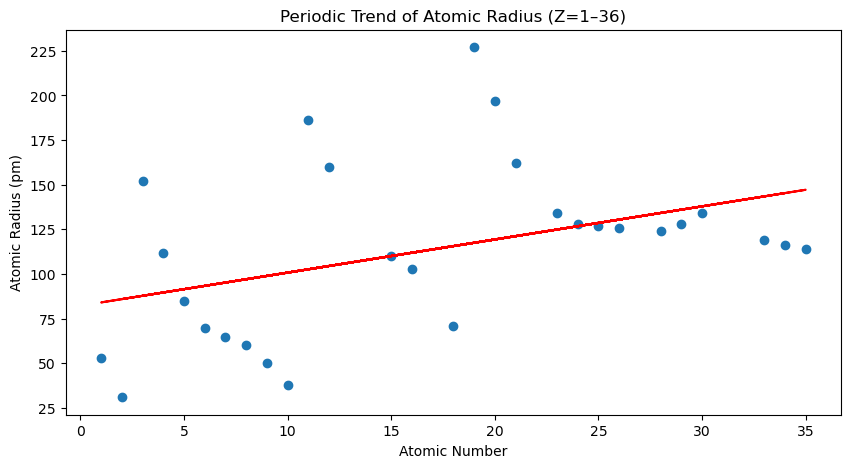

In [20]:
#Let's use this model on the X training data to make predictions and compare with actual values
y_train_predict = model.predict(X_train)

plt.figure(figsize=(10,5))
plt.scatter(X_train,y_train) #Original data
plt.plot(X_train,y_train_predict,color='red') #Predicted data - add some colour
plt.xlabel("Atomic Number")
plt.ylabel("Atomic Radius (pm)")
plt.title("Periodic Trend of Atomic Radius (Z=1–36)")
plt.show()


Obviously, a straight line doesn't work- but we are just doing this as an exercise remember? 💪

**Another metric that can be checked is mean absolute error**

❓  Look up the Scikit-learn documentation on Mean absolute error (MAE), and write a code to compute the MAE value for the training data.

Alternatives: Mean Squared Error (MSE), Root Mean Squared Error (RMSE)

In [54]:
#MAE  - overal good metric

mae_train = mean_absolute_error(y_train,y_train_predict)
print("MAE train:",mae_train)

#✅ MSE  - sensitive to outliers
mse_train = mean_squared_error(y_train,y_train_predict)
print("MSE train:",mse_train)

#✅ TO compare MAE Vs MSE, use RMSE
rmse = math.sqrt(mse_train)
print("RMSE train:",rmse)

MAE train: 33.12209149799205
MSE train: 1873.4770044195102
RMSE train: 43.28368057847565


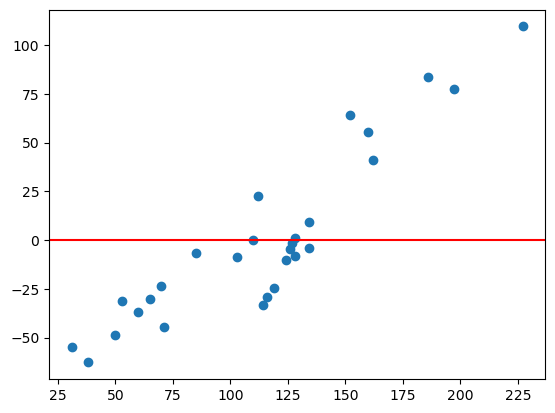

In [22]:
#Residual plot
plt.scatter(y_train, y_train - y_train_predict)
plt.axhline(0,color='red')

See how the residuals clearly show a pattern? 
That just means our model (straight line) is failing to capture the true relationship between the features.

$\rightarrow $ just proves our earlier point that we learnt.

# 🧪 Testing
If you want to test the model  : need to use the test datasets

You can use the same metrics / plots to see how well the model performs


**❓Find the r2 value and the MAE for the Test set**

**❓Then plot the original test data & the regression line**

 What do you think?

In [23]:
# r2 test
r2_test= model.score(X_test,y_test)
print("R² test:", r2_test)
# MAE test
mae_test = mean_absolute_error(y_test,model.predict(X_test))
print("MAE test:",mae_test)

R² test: -1.178704869384923
MAE test: 22.235008475773412


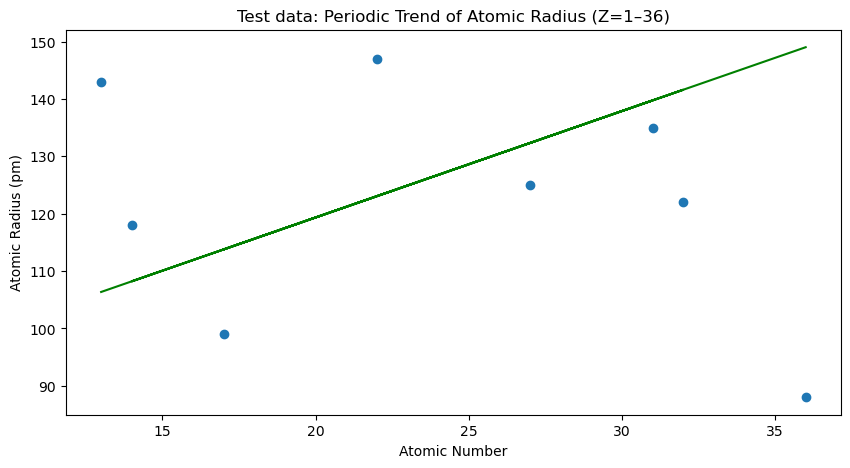

In [24]:
# plot test
y_test_predict = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.scatter(X_test,y_test) #Original data
plt.plot(X_test,y_test_predict,color='green') #Predicted data
plt.xlabel("Atomic Number")
plt.ylabel("Atomic Radius (pm)")
plt.title("Test data: Periodic Trend of Atomic Radius (Z=1–36)")
plt.show()


# ❓ How much does the test R² depend on the split itself?

We only tried **one** 80/20 split (`random_state=42`). With just 36 elements total, the test
set has only 7 rows - so this R² could look quite different with a different split, even
though nothing about the model itself changed.

Refit the single-variable model for a handful of different `random_state` values and record
the test R² each time. How much does it move around? What does that tell you about trusting
a single train/test split on a small dataset?

In [55]:
# ✅ Test R² across several different random_state values

r2_by_seed = []
for state in range(5):
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(X, y, test_size=0.2, random_state=state)
    m = LinearRegression()
    m.fit(Xs_train, ys_train)
    r2_by_seed.append(m.score(Xs_test, ys_test))
    print(f"random_state={state}: test R² = {r2_by_seed[-1]:.3f}")

print(f"\nrange across seeds: {min(r2_by_seed):.3f} to {max(r2_by_seed):.3f}")

# With only ~7 test points, a single split's R² is a noisy estimate of "true" performance -
# one unlucky (or lucky) split can swing it a lot. This is exactly why, with small datasets,
# k-fold cross-validation (averaging performance over several splits) is usually preferred
# over judging a model from one train/test split.

random_state=0: test R² = -1.628
random_state=1: test R² = -0.153
random_state=2: test R² = 0.276
random_state=3: test R² = 0.039
random_state=4: test R² = 0.084

range across seeds: -1.628 to 0.276


💡 We only used one x variable (Atomic number) for our prediction, but the model would be more accurate if you used other variables like Period or Group.

➡ This means multi-variable regression (but still linear).

Multi-variable regression is where you use multiple features to predict one outcome.

In [56]:
#Let's add a few more X variables (multi-variable)

X_multi = df[["Atomic_Number","Period","Group"]]
y = df["Atomic_Radius_pm"]

#Split the data
# same random_state=42 as the single-variable split above, so R² values are comparable
X_multi_train,X_multi_test,y_train,y_test = train_test_split(X_multi,y,test_size=0.2,random_state=42)

#New model now
model_multi = LinearRegression()
model_multi.fit(X_multi_train,y_train)

print("R²:", model_multi.score(X_multi_train,y_train))

R²: 0.8567080871113633


# ❓ Can you obtain the coefficients of the multi-variable model

This time, since it's a multi-variable regression, you should get multiple coefficients (how many?)

In [27]:
#✅ Coefficients of the multi-variable model
print("coefficients:",model_multi.coef_,"intercept:",model_multi.intercept_)

coefficients: [-3.01772454 56.85869777 -3.1136194 ] intercept: 23.258055498250116


In [28]:
# MAE of the multi-variable model
y_multi_train_predict = model_multi.predict(X_multi_train)
mae_multi_train = mean_absolute_error(y_train,y_multi_train_predict)
print("MAE:",mae_multi_train)

mse_multi_train = mean_squared_error(y_train,y_multi_train_predict)
print("RMSE:",math.sqrt(mse_multi_train))


MAE: 15.09005997359573
RMSE: 17.941780166635834


#  🪱 Let's try a polynomial fit

Although Polynomial curves are non-linear, in python we still use the same linear algebra tools as linear regression - so it is still a linear model

In [29]:
#let's start with a degree 2, (and try 3,4,5)

degree = 4
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X_train)

model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
print("R^2 with polynomial:", model_poly.score(X_poly, y_train))

R^2 with polynomial: 0.31622372951296684


C:\Users\Sasani\AppData\Local\anaconda3\envs\mle5217\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


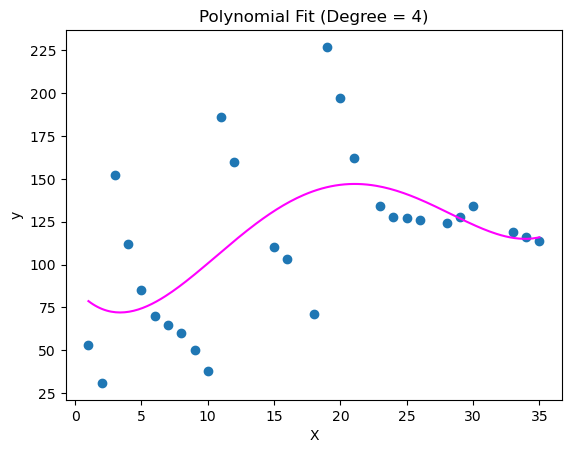

In [30]:
#Let's plot the polynomials and see
# Create smooth X values
X_plot = np.linspace(X_train.values.min(), X_train.values.max(), 200).reshape(-1, 1)

# Transform them
X_plot_poly = poly.transform(X_plot)

# Predict
y_plot = model_poly.predict(X_plot_poly)

# Plot
plt.figure()
plt.scatter(X_train, y_train)
plt.plot(X_plot, y_plot,color='magenta')
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Fit (Degree = {degree})")
plt.show()

In [31]:
#Maybe it's better to try with multi-variable regression - We can't visualize this
#(this is just a quick one-off check on the training set - we do this properly, with a
#test-set comparison across several degrees, in the next few cells)

multi_poly = PolynomialFeatures(degree=3)
X_multi_poly = multi_poly.fit_transform(X_multi_train)

model_multi_poly = LinearRegression()
model_multi_poly.fit(X_multi_poly, y_train)
print("R^2 with polynomial:", model_multi_poly.score(X_multi_poly, y_train))

R^2 with polynomial: 0.9961695916685002


In [32]:
#How do we know which polynomial degree would work best?
#Important: judging this from TRAINING error alone is misleading - a higher-degree polynomial
#can basically always fit the training points at least as well, so training MAE will just keep
#dropping regardless of whether the model is actually any good. We need to track TEST error
#too, since that's what tells us whether the extra flexibility is helping or just memorizing
#noise in these particular 28 training rows.

mae_train_arr, mae_test_arr = [], []
r2_train_arr, r2_test_arr = [], []
n_features_arr = []

for degree in range(1,6):   #iterate through a range of degree values
    poly_features = PolynomialFeatures(degree=degree,include_bias=False)
    X_multi_poly_train = poly_features.fit_transform(X_multi_train)      #fit on TRAIN only
    X_multi_poly_test = poly_features.transform(X_multi_test)            #then just transform test

    model_multi_poly = LinearRegression()
    model_multi_poly.fit(X_multi_poly_train, y_train)

    y_train_pred = model_multi_poly.predict(X_multi_poly_train)
    y_test_pred = model_multi_poly.predict(X_multi_poly_test)

    mae_train_arr.append(mean_absolute_error(y_train, y_train_pred))
    mae_test_arr.append(mean_absolute_error(y_test, y_test_pred))
    r2_train_arr.append(r2_score(y_train, y_train_pred))
    r2_test_arr.append(r2_score(y_test, y_test_pred))
    n_features_arr.append(X_multi_poly_train.shape[1])

print(f"polynomial features per degree: {n_features_arr}   (we only have {len(X_multi_train)} training rows!)")
print(f"MAE train: {[round(v,2) for v in mae_train_arr]}")
print(f"MAE test:  {[round(v,2) for v in mae_test_arr]}")
print(f"R2 train:  {[round(v,3) for v in r2_train_arr]}")
print(f"R2 test:   {[round(v,3) for v in r2_test_arr]}")

polynomial features per degree: [3, 9, 19, 34, 55]   (we only have 28 training rows!)
MAE train: [15.09, 8.44, 1.99, 1.19, 0.92]
MAE test:  [15.14, 16.38, 8.48, 10.0, 6.82]
R2 train:  [0.857, 0.95, 0.996, 0.998, 0.999]
R2 test:   [0.194, -0.218, 0.559, 0.445, 0.682]


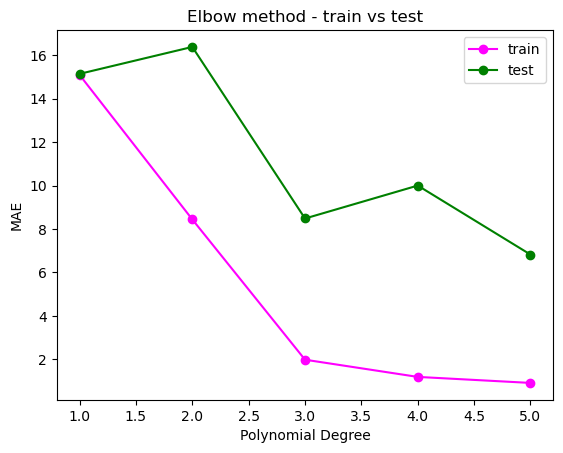

In [33]:
plt.plot(range(1,6),mae_train_arr,color='magenta',marker='o',label='train')
plt.plot(range(1,6),mae_test_arr,color='green',marker='o',label='test')
plt.xlabel("Polynomial Degree")
plt.ylabel("MAE")
plt.title('Elbow method - train vs test')
plt.legend()
plt.show()

# The real "elbow" is wherever test MAE stops improving (or starts getting worse) even as
# train MAE keeps falling - that gap is overfitting in action. A degree chosen on train MAE
# alone (the original version of this cell) would have just kept climbing to the highest
# degree tried, since more parameters can never make the TRAINING fit worse.

In [34]:
#Pick the degree with the optimum (lowest) TEST MAE - not train MAE, since train MAE
#basically always favours the highest degree tried (see the plot above)
best_degree = int(np.argmin(mae_test_arr)) + 1   # +1: mae_test_arr[0] is degree 1, so index -> degree needs +1
print(f"Best polynomial degree (by test MAE): {best_degree}")

#Plotting is not straightforward since this is multi-dimensional

Best polynomial degree (by test MAE): 5


# Write the code to fit the optimum polynomial and obtain the metrics and coefficients

Also report its R² and MAE on the **test** set - that's the number that actually reflects how
well this choice of degree generalizes, not just how well it memorized the training rows.

In [35]:
# ✅ Optimum polynomial
multi_poly_best = PolynomialFeatures(best_degree)
X_multi_poly_train_best = multi_poly_best.fit_transform(X_multi_train)
X_multi_poly_test_best = multi_poly_best.transform(X_multi_test)

model_multi_poly_best = LinearRegression()
model_multi_poly_best.fit(X_multi_poly_train_best, y_train)

print("R² train:", model_multi_poly_best.score(X_multi_poly_train_best, y_train))
print("R² test: ", model_multi_poly_best.score(X_multi_poly_test_best, y_test))
print("MAE test:", mean_absolute_error(y_test, model_multi_poly_best.predict(X_multi_poly_test_best)))

R² train: 0.9986675028749495
R² test:  0.6815993302942555
MAE test: 6.8232715114481834


# ❗ A high $r^2$ does not necessarily mean the fit is good!

- A polynomial can mathematically approximate this pattern, but that does not mean it is a physically meaningful model. ⭐The science doesn't add up.

- $r^2$ squared is a measure of variance explained - it simply means that and not science explained

A flexible curve can follow the up-down oscillations and reduce residual error, which is specially true when data set is small, polynomial degree is high & periodic structure exists.

- The X variables are not independent features - more on this later.

- The train-vs-test MAE plot above is exactly this idea in action: train error kept improving as degree increased, but that alone isn't evidence of a better model - the test curve is what actually tells you whether the extra flexibility generalizes.
--------------------------------------------------------------------------------


--------------------------------
Everything below is *advanced* at this stage.
We will talk about multi-colinearity and Random Forests much later in the course. 

If what we have done up to now is already too much to take in 😭😭 - you can stop here.

If you are still feeling ok 😉 - just have a quick look at the below sections - no pressure, you don't have to understand them - just know they exist so that once we come back to them later you will recognize them!

# ❓ Let's check that "not independent features" claim

Above we said *Atomic_Number*, *Period* and *Group* aren't really independent of each other - for
elements 1-36, knowing Period and Group tells you almost exactly which element (and therefore
which Atomic_Number) you have.

Compute the correlation matrix for `["Atomic_Number","Period","Group"]` and visualize it as a
heatmap. Based on what you see, does it make sense to read the multi-variable regression
coefficients above (cell with `model_multi.coef_`) as "how much Atomic_Radius changes per unit
of Atomic_Number, holding Period and Group fixed"?

               Atomic_Number    Period     Group
Atomic_Number       1.000000  0.910469  0.167205
Period              0.910469  1.000000 -0.128326
Group               0.167205 -0.128326  1.000000


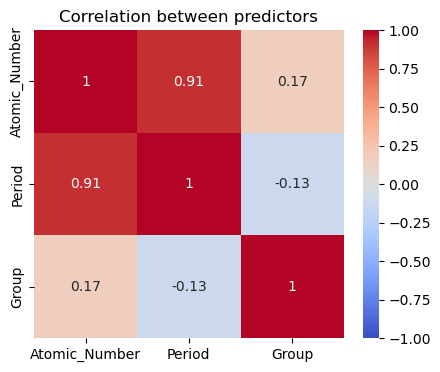

In [36]:
# ✅ Correlation between the three "independent" variables

corr_features = df[["Atomic_Number","Period","Group"]].corr()
print(corr_features)

plt.figure(figsize=(5,4))
sns.heatmap(corr_features, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between predictors")
plt.show()

# For Z=1-36, Atomic_Number and Period are strongly correlated (r ≈ 0.91) - which makes sense,
# since Period basically counts "how many elements have come before, in blocks of 8/8/18".
# Atomic_Number vs Group and Period vs Group are both weak (|r| < 0.2), since Group cycles
# repeatedly rather than trending with Atomic_Number.
# This is multicollinearity: because Atomic_Number and Period carry a lot of the same
# information, the model can trade coefficient weight between them without changing its
# predictions much - so a single coefficient like model_multi.coef_[0] should NOT be read as
# "the isolated effect of Atomic_Number, holding Period and Group fixed". That interpretation
# assumes independent predictors, and here they clearly aren't.

# 🌳🌳 Random Forest Regressor

A Random forest is a collection of decision trees - a powerful classical ML algorithm widely used in Materials science.

It has many parameters and flexibility to adapt to different conditions, including non-linear relationships.

It can also be adapted for regression problems (RF Regressor) or classification problems (RF Classifier)

In [57]:
#As it is with any ML model, Let's start by creating an instance of it
rf = RandomForestRegressor(n_estimators=100, random_state=42,max_features="sqrt")
rf.fit(X_multi_train,y_train)

print("RF R²:", rf.score(X_multi_train,y_train))

RF R²: 0.9593085679181135


# Visualization
Random forests are not easy to visualize, but to understand what's happening
we can visualize a **single tree**

For this we will need to install a specialized package called graphviz.

So if you want to run this part, go to your **Anaconda Prompt** and run

*conda install -c conda-forge python-graphviz*

Or else you can simply have a look here.


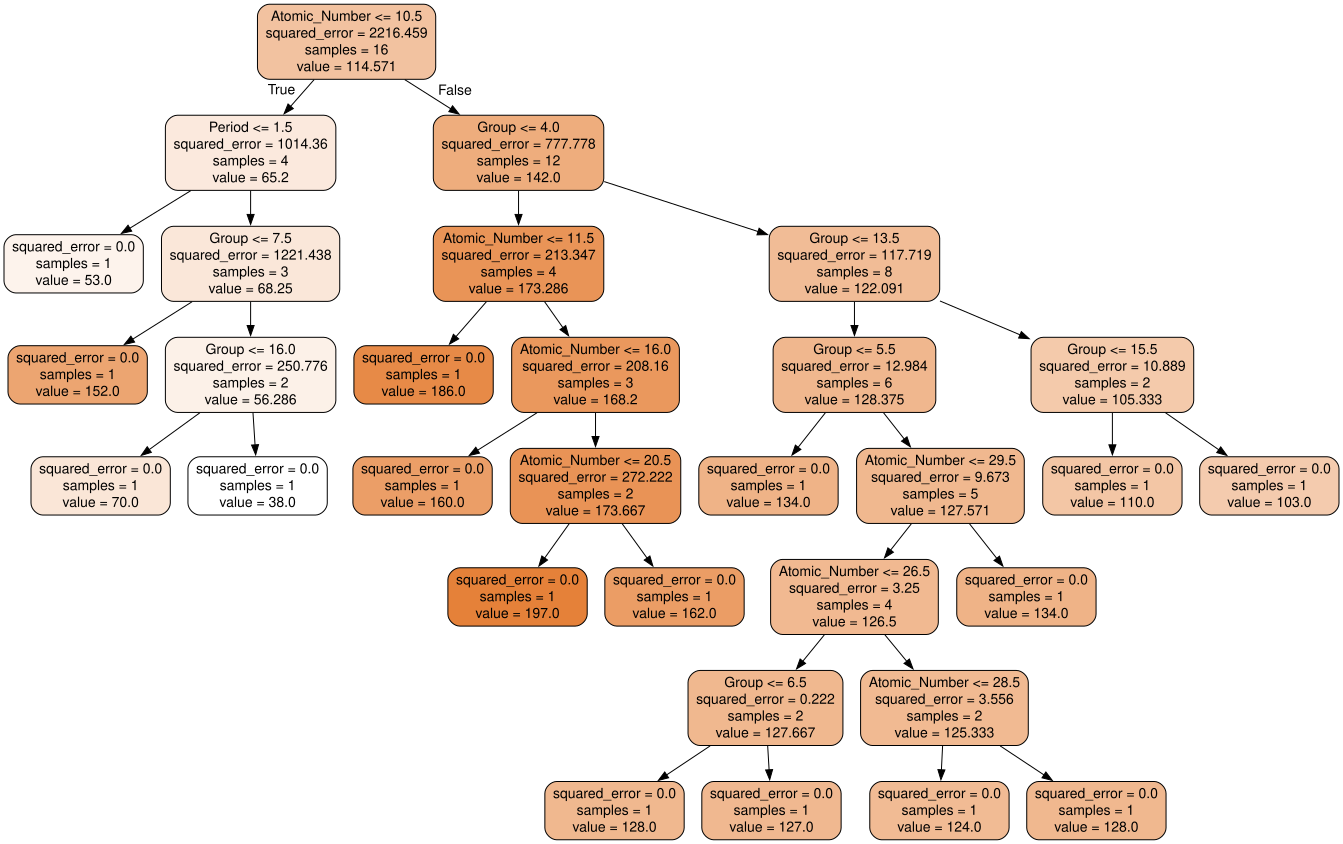

In [40]:
from sklearn.tree import export_graphviz
import graphviz

tree = rf.estimators_[0]

dot_data = export_graphviz(tree,
                           filled=True,
                           rounded=True,
                           feature_names=X_multi.columns,
                           out_file=None)

graph = graphviz.Source(dot_data)
graph

# ❓ 
If you are running the code, here's a small challenge for you to try out.

It's a bit confusing to see X1, X2 & X3 in the tree,

Can you modify them so that the actual feature names are displayed rather than variable names?

*X_multi = df[["Atomic_Number","Period","Group"]]*

In [ ]:
# ✅ modify the above code to use the column names instead of X1,X2 & X3







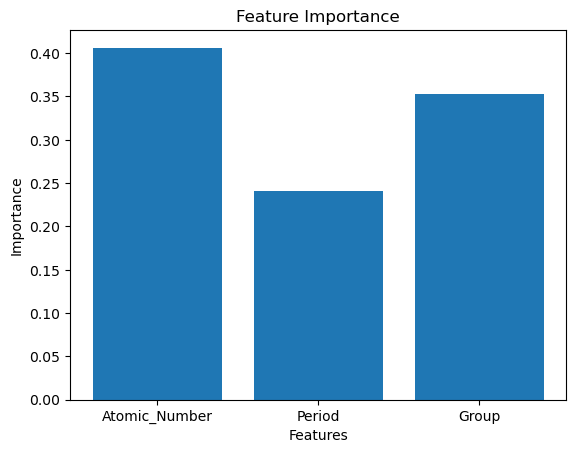

In [41]:
# Which features are more important in determining the prediction of the target
importances = rf.feature_importances_
plt.bar(X_multi_train.columns,importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

# 📊 ❓
Can you sort these features in order and plot, so that it's easier to see

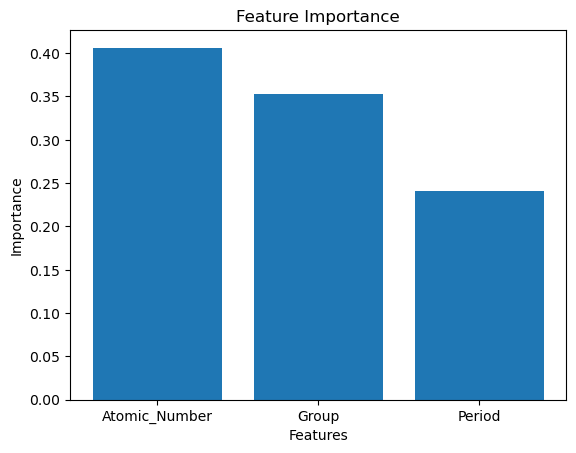

In [42]:
# ✅ Sort the feature importance

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.bar(X_multi_train.columns[indices],importances[indices])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()




#Let's evaluate the performance of the Random Forest Regressor

Use the Test set, compute the r2 value

In [43]:
# Predict on test set
y_test_pred = rf.predict(X_multi_test)

# Compute R²
r2_test = r2_score(y_test, y_test_pred)

print("Test R²:", r2_test)

Test R²: 0.697438567001995


# Over-fitting Vs Under-fitting
:
Look at the $r^2$ values for the training and testing sets, If:

Train ≫ Test → Overfitting

Train ≈ Test → Good generalization

Both low → Underfitting

# ❔ What to do in case of Over / Under fit

 - Modify parameters of the model - more on that later!
 - Cross Validation - more on that later!

We'll come back to this exact rubric further down and apply it to the Random Forest
**Classifier** as well.
-------------------------------------------------------------------------------


# 🌳🌳 Random Forest Classifier

For a classification problem we need two (or more) classes of data.

Since our data is not inherently classified, let's break it into two classes.

Light elements : atomic radius <100 pm

Heavy elements : atomic radius >=100 pm

Then build a model so that if we present the model with an unknown datpoint, it can correctly classify whether it is light or heavy only based on the X values

In [44]:
# Threshold
threshold = 100

df["Light_Heavy"] = np.where(
    df["Atomic_Radius_pm"] < threshold,
    0,   # 0 = Light
    1    # 1 = Heavy
)

df[["Element","Atomic_Radius_pm","Light_Heavy"]].head()

,Element,Atomic_Radius_pm,Light_Heavy
0,H,53,0
1,He,31,0
2,Li,152,1
3,Be,112,1
4,B,85,0


In [45]:
#Separating the X and y
# Note: Electronegativity still has 4 missing values (the noble gases) at this point - we
# deliberately did NOT fill them earlier. We'll impute them properly, using train-set
# statistics only, right after the split below.
X_class = df[["Atomic_Number","Period","Group","Electronegativity"]]
y_class = df["Light_Heavy"]
X_class.head()

,Atomic_Number,Period,Group,Electronegativity
0,1,1,1,2.20
1,2,1,18,NaN
2,3,2,1,0.98
3,4,2,2,1.57
4,5,2,13,2.04


In [46]:
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

# ⚡ Now let's actually impute Electronegativity properly

Earlier we filled the missing Electronegativity values (the noble gases) using the mean of
the *whole* dataset, before any split existed - fine for a quick look, but not fine now that
Electronegativity is an actual model feature: filling it that way would let information about
the test rows leak into a number the "training" pipeline depends on.

Since we've already split into `X_class_train` / `X_class_test`, let's compute the fill value
from the training set only, and apply that same value to both.

In [47]:
# Compute the imputation value from the TRAINING set only
en_train_mean = X_class_train["Electronegativity"].mean()
print("Electronegativity mean computed from training data only:", en_train_mean)

# Apply the same value to both train and test - the test set never contributes to this number
X_class_train = X_class_train.copy()
X_class_test = X_class_test.copy()
X_class_train["Electronegativity"] = X_class_train["Electronegativity"].fillna(en_train_mean)
X_class_test["Electronegativity"] = X_class_test["Electronegativity"].fillna(en_train_mean)

print("\nRemaining missing values -> train:", X_class_train.isna().sum().sum(),
      " test:", X_class_test.isna().sum().sum())

Electronegativity mean computed from training data only: 1.9095833333333332

Remaining missing values -> train: 0  test: 0


In [48]:
#For this we use Rnadom forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_clf.fit(X_class_train, y_class_train)

print("Train Accuracy:", rf_clf.score(X_class_train, y_class_train))
print("Test Accuracy:", rf_clf.score(X_class_test, y_class_test))

Train Accuracy: 1.0
Test Accuracy: 0.7272727272727273


In [49]:
#Based on the test set, predict what the outcome is according to the model
y_class_pred = rf_clf.predict(X_class_test)

print("\nClassification Report:")
print(classification_report(y_class_test, y_class_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.67      1.00      0.80         6

    accuracy                           0.73        11
   macro avg       0.83      0.70      0.69        11
weighted avg       0.82      0.73      0.70        11



# ❓ Apply the Over/Under-fitting rubric to the classifier

Back in the Random Forest **Regressor** section we used this rubric:

Train ≫ Test → Overfitting

Train ≈ Test → Good generalization

Both low → Underfitting

Look at the classifier's train accuracy versus its test accuracy above. Where does it fall on
that rubric? Try changing one parameter of `RandomForestClassifier` below (e.g. `max_depth`,
`min_samples_leaf`) and see whether you can close the gap - what happens to test accuracy when
you do?

In [50]:
# ✅ Try a more constrained forest and compare

rf_clf_v2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,          # was 5 - shallower trees are less able to memorize the training set
    min_samples_leaf=2,   # require a bit more data per leaf
    random_state=42
)
rf_clf_v2.fit(X_class_train, y_class_train)

print("Train Accuracy:", rf_clf_v2.score(X_class_train, y_class_train))
print("Test Accuracy:", rf_clf_v2.score(X_class_test, y_class_test))

# Also worth remembering: the test set here is only ~11 elements, so a single accuracy number
# can shift a lot from just one or two predictions flipping - treat small changes as noise,
# not necessarily a real improvement. (Same caution as the random_state exercise earlier.)

Train Accuracy: 1.0
Test Accuracy: 0.7272727272727273


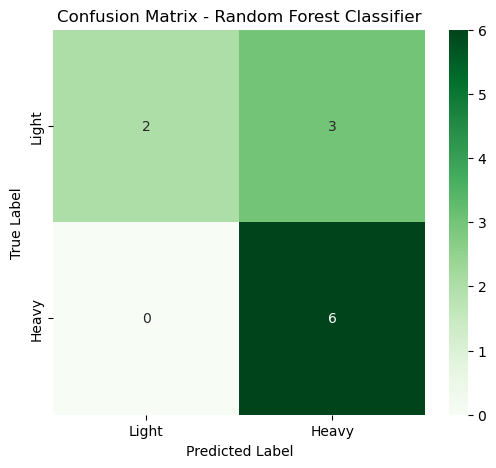

In [51]:
# Compute confusion matrix
cm = confusion_matrix(y_class_test, y_class_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=["Light", "Heavy"],
            yticklabels=["Light", "Heavy"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

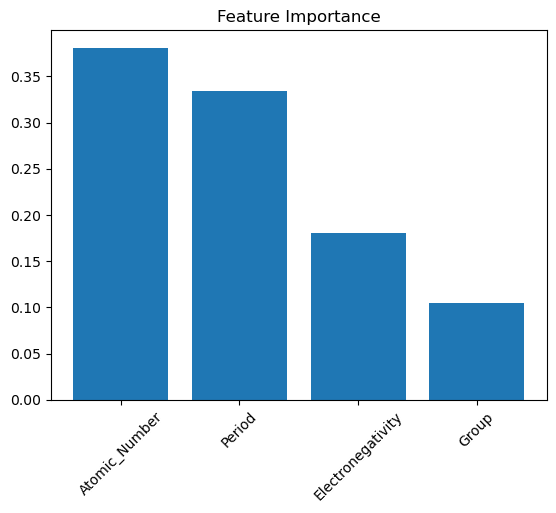

In [52]:
#Feature importance for classification
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print
plt.bar(X_class.columns[indices], importances[indices])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# 🔥 In Summary

- Import data
- Brief data exploration & cleaning
  - being careful about *when* you compute imputation statistics (train-only, not the whole dataset)
- Train - test split
  - using a consistent random_state so models are compared fairly
  - checking how much a result depends on the particular split (small-dataset caution)
- Linear Regression
  - single variable
  - multi-variable
  - checking predictors for multicollinearity before over-interpreting coefficients
- Polynomial Regression
  - single variable
  - multi-variable
  - finding optimum polynomial degrees using TEST error, not training error
- Considerations in interpreting performance metrics
- Random Forest
  - Regression
  - Classification
  - applying the overfit/underfit rubric to both
